In [4]:
import geopandas as gpd

In [5]:
wi = gpd.read_file('./wisconsin.topojson')

In [9]:
mnd = gpd.read_file('./mound_sites.json')

<Axes: >

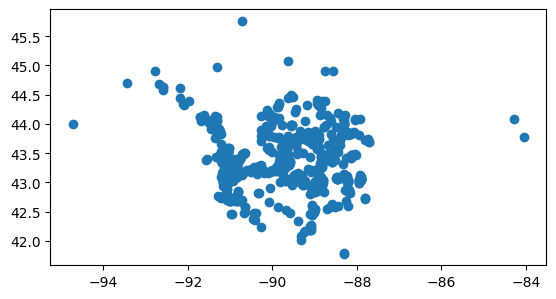

In [22]:
mnd.plot()

In [23]:
len(mnd)

1041

# Let's look at some candidate aggregation administrative units

In [11]:
townshipsPath = r'C:\Users\eagle\OneDrive\Documents\Data\Wisconsin Boundaries\WI_PLSSTownships_1996\plss_townships\WI_PLSSTownships_1996.shp'
municipalPath = r'C:\Users\eagle\OneDrive\Documents\Data\Wisconsin Boundaries\WI_Municipalboundaries_Spring_2026\WI_CTV_Jan_2026.shp'
countySupPath = r'C:\Users\eagle\OneDrive\Documents\Data\Wisconsin Boundaries\WI_County_Supervisory_Districts_Fall_2025\WI_County_Supervisory_Districts_Fall_2025.shp'
tractsPath = r'C:\Users\eagle\OneDrive\Documents\Data\Wisconsin Boundaries\WI_CensusTL_Tracts_2025\WI_CensusTL_Tracts_2025.shp'
countySubPath = r'C:\Users\eagle\OneDrive\Documents\Data\Wisconsin Boundaries\WI_CensusTL_CountySubdivisions_2025\WI_CensusTL_CountySubdivisions_2025.shp'
countyPath = r'C:\Users\eagle\OneDrive\Documents\Data\Wisconsin Boundaries\WI_CensusTL_Counties_2025\WI_CensusTL_Counties_2025.shp'
blockPath = r'C:\Users\eagle\OneDrive\Documents\Data\Wisconsin Boundaries\WI_CensusTL_BlockGroups_2025\WI_CensusTL_BlockGroups_2025.shp'

WI_PLSSTownships_1996.shp
WI_CTV_Jan_2026.shp
WI_County_Supervisory_Districts_Fall_2025.shp
WI_CensusTL_Tracts_2025.shp
WI_CensusTL_CountySubdivisions_2025.shp
WI_CensusTL_Counties_2025.shp
WI_CensusTL_BlockGroups_2025.shp


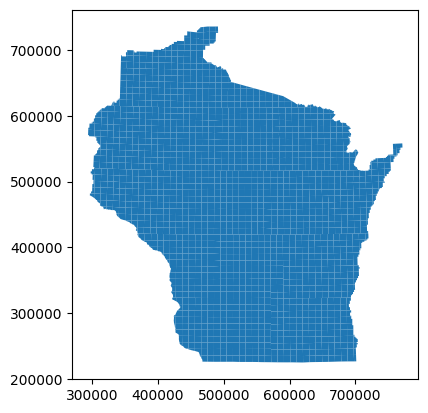

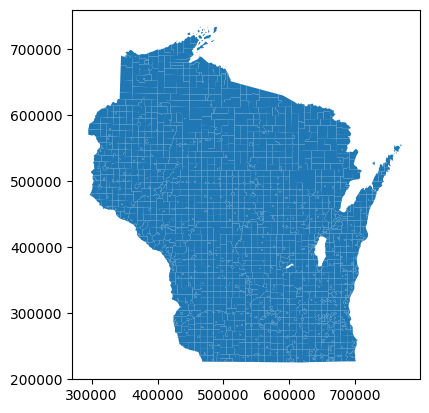

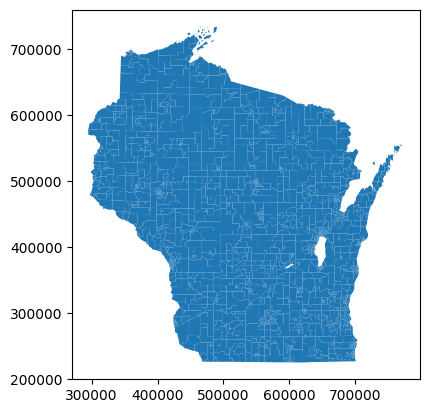

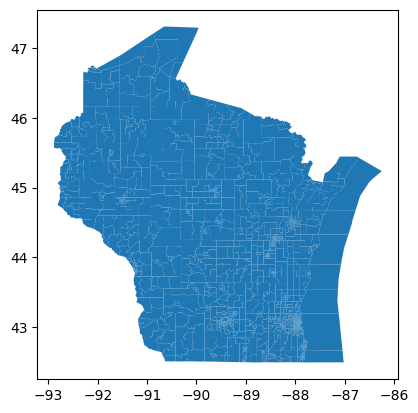

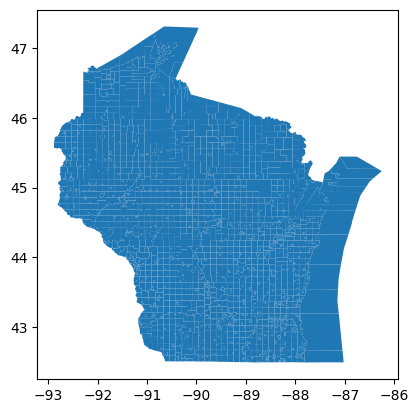

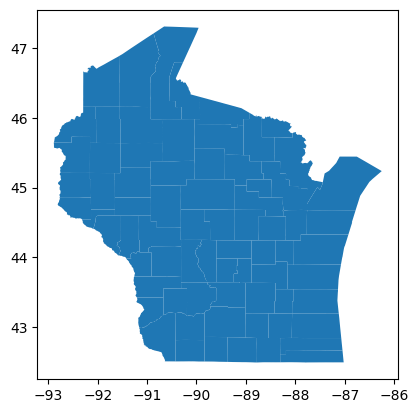

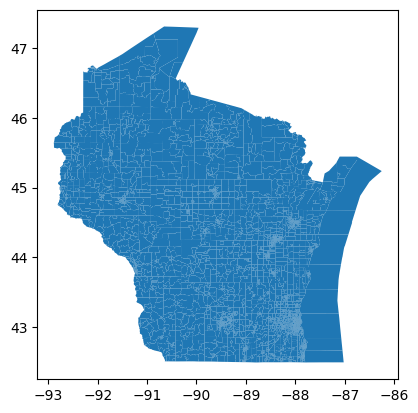

In [ ]:
for path in [townshipsPath, municipalPath, countySupPath,
             tractsPath, countySubPath, countyPath, blockPath]:
    print(path.split('\\')[-1])
    gpd.read_file(path).plot()

Let's try aggregating by township then county.

# Aggregation

In [24]:
mnd.columns

Index(['Site Name', 'County', 'Site No', 'Locality', 'Cluster', 'Zone', 'East',
       'North', 'Landform', 'Water', 'Viewshed', 'Bird', 'Fork Tailed Bird',
       'Goose', 'Bear', 'Panther', 'Long Tailed Quadruped',
       'Short Tailed Quadruped', 'Unknown Quadruped', 'Water Spirit',
       'Long Tailed Turtle', 'Short Tailed Turtle', 'No Tailed Turtle',
       'Unknown Turtle', 'Mink', 'geometry'],
      dtype='str')

In [32]:
mnd['Cluster'].unique()

<StringArray>
[          'Petenwell',       'Lakes Cluster',             'Isolate',
           'Site Pair',             'Nekoosa',      'Lake Winnebago',
         'Lower Dells',            'Merrimac',          'Four Lakes',
        'Sauk Prairie',      'Colladay Point',          'Pine Bluff',
     'West Koshkonong',             'Kegonsa',        'East Horicon',
     'Boiling Springs',       'South Horicon',           'Hustiford',
            'Nitschke',            'Fox Lake',                'Road',
           'Kolterman',          'Beaver Dam',          'Sugar Loaf',
     'East Green Lake',            'Puckaway', 'Grand River Springs',
           'Princeton',          'Koshkonong',             'Aztalan',
         'East Branch',         'Lake Ripley',           'Rock Lake',
             'Outlier',        'Buffalo Lake',       'Pleasant Lake',
           'Milwaukee',     'Wisconsin River',              'Racine',
              'Beloit',        'Spring Green',             'Baraboo',
      

Interesting, lots of watershed areas. Let's check some water boundary aggregate candidates.

## Check candidate watershed units

In [39]:
watershedManagementPath = r'C:\Users\eagle\OneDrive\Documents\Data\Wisconsin Boundaries\WI_Water_Management_Units_2022\WI_Water_Management_Units_2022.shp'
watershedPath = r'C:\Users\eagle\OneDrive\Documents\Data\Wisconsin Boundaries\WI_Watersheds_2017\WI_Watersheds_2017.shp'
subWatershedPath = r'C:\Users\eagle\OneDrive\Documents\Data\Wisconsin Boundaries\WI_Hydro_12digit_Subwatersheds_2017\WI_Hydro_12digit_Subwatersheds_2017.shp'
subBasinPath = r'C:\Users\eagle\OneDrive\Documents\Data\Wisconsin Boundaries\WI_Hydro_8digit_Subbasins_2017\WI_Hydro_8digit_Subbasins_2017.shp'

The rankings for these really are

| Level | Name         | Digits | Typical scale                    |
| ----- | ------------ | ------ | -------------------------------- |
| 1     | Region       | 2      | Multi-state (major river basins) |
| 2     | Subregion    | 4      | Large river systems              |
| 3     | Basin        | 6      | Major tributary basins           |
| 4     | Subbasin     | 8      | Mid-sized watersheds             |
| 5     | Watershed    | 10     | Local drainage areas             |
| 6     | Subwatershed | 12     | Very fine catchments             |


WI_Water_Management_Units_2022.shp
WI_Hydro_8digit_Subbasins_2017.shp
WI_Watersheds_2017.shp
WI_Hydro_12digit_Subwatersheds_2017.shp


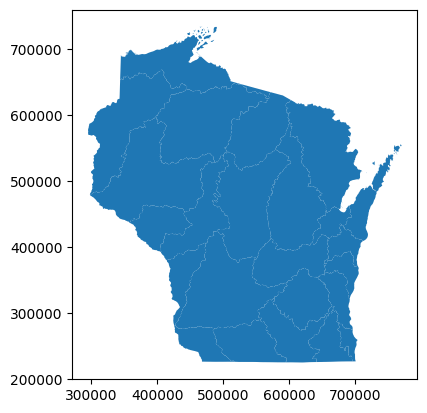

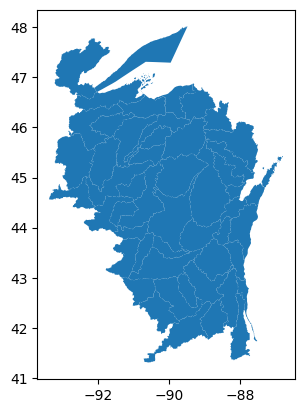

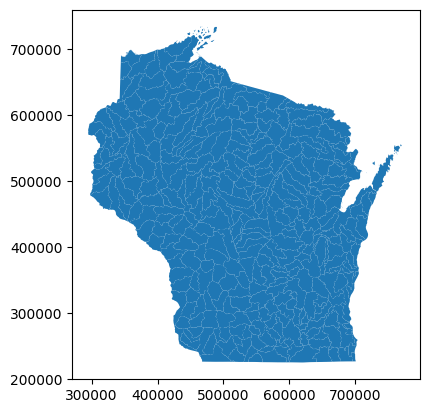

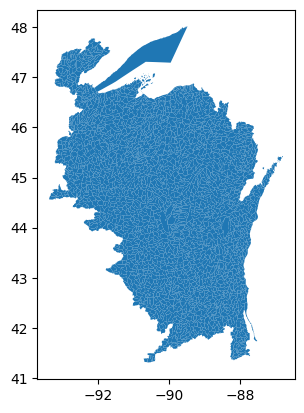

In [41]:
for path in [watershedManagementPath, subBasinPath, watershedPath, subWatershedPath]:
    print(path.split('\\')[-1])
    gpd.read_file(path).plot()

## Try Sub-basin Aggregation

We have 'Bird', 'Fork Tailed Bird', 'Goose', 'Bear', 'Panther', 'Long Tailed Quadruped', 'Short Tailed Quadruped', 'Unknown Quadruped', 'Water Spirit', 'Long Tailed Turtle', 'Short Tailed Turtle', 'No Tailed Turtle', 'Unknown Turtle', 'Mink' mound animal species to check

In [42]:
sbb = gpd.read_file(subBasinPath)

In [44]:
mnd = mnd.to_crs(sbb.crs)

In [45]:
mndsbb = gpd.sjoin(mnd, sbb, how = "left", predicate = "within")

In [46]:
mndsbb

,Site Name,County,Site No,Locality,Cluster,Zone,East,North,Landform,Water,...,No Tailed Turtle,Unknown Turtle,Mink,geometry,index_right,OBJECTID,HUC8_CODE,HUC8_NAME,Shape__Are,Shape__Len
0,AD-0027,Adams,AD-0027,Central Wisc,Petenwell,16,262043.0,4888298.0,Terrace,River,...,0.0,0.0,0.0,POINT (-89.97342 44.10917),36.0,87.0,07070003,Castle-Rock,8.409344e+09,851324.454944
1,Crooked Lake,Adams,AD-0041,Central Wisc,Lakes Cluster,16,289769.0,4849085.0,Terrace,Lake,...,0.0,0.0,0.0,POINT (-89.61185 43.76497),14.0,65.0,04030201,Upper Fox River,4.193402e+09,435724.885328
2,Dead Horse Slough,Adams,AD-0005,Central Wisc,Isolate,16,272694.0,4886302.0,Terrace,Creek,...,0.0,0.0,0.0,POINT (-89.83963 44.09461),36.0,87.0,07070003,Castle-Rock,8.409344e+09,851324.454944
3,Douglas Effigy,Adams,AD-0056,Central Wisc,Site Pair,16,271254.0,4849563.0,Terrace,River,...,0.0,0.0,0.0,POINT (-89.84181 43.76379),36.0,87.0,07070003,Castle-Rock,8.409344e+09,851324.454944
4,Fourth Drive North,Adams,AD-0197,Baraboo Range,Site Pair,16,284973.0,4837352.0,Hillslopes,Upland,...,0.0,0.0,0.0,POINT (-89.66669 43.65807),14.0,65.0,04030201,Upper Fox River,4.193402e+09,435724.885328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036,Zumbro Valley,Wabasha,WB-0023,Upper Miss,Site Pair,15,572572.0,4908657.0,Terrace,River,...,0.0,0.0,0.0,POINT (-92.0898 44.32755),NaN,NaN,NaN,NaN,NaN,NaN
1037,WA-0010,"Washington, MN",WA-0010,Upper Miss,Isolate,15,517195.0,4971654.0,Terrace,River,...,0.0,0.0,0.0,POINT (-92.78222 44.8981),3.0,54.0,07030005,Lower St. Croix River,6.785969e+09,576582.220695
1038,WN-0005,Winona,WN-0005,Trempealeau,Isolate,15,624997.0,4864024.0,Ridge,Creek,...,0.0,0.0,0.0,POINT (-91.44306 43.91872),0.0,51.0,07040006,La Crosse-Pine Rivers,1.799071e+09,313917.549318
1039,WN-0007,Winona,WN-0007,Trempealeau,Isolate,15,627050.0,4869053.0,Terrace,River,...,0.0,0.0,0.0,POINT (-91.4163 43.96364),0.0,51.0,07040006,La Crosse-Pine Rivers,1.799071e+09,313917.549318


In [47]:
types = ['Bird', 'Fork Tailed Bird', 'Goose', 'Bear', 
         'Panther', 'Long Tailed Quadruped', 'Short Tailed Quadruped', 
         'Unknown Quadruped', 'Water Spirit', 'Long Tailed Turtle', 
         'Short Tailed Turtle', 'No Tailed Turtle', 'Unknown Turtle', 'Mink']

In [48]:
mndsbbagg = (
    mndsbb
    .groupby("HUC8_CODE")[types]
    .sum()
    .reset_index()
)

In [50]:
mndsbbagg["Total"] = mndsbbagg[types].sum(axis=1)

In [51]:
for t in types:
    mndsbbagg[f"{t} Proportion"] = mndsbbagg[t] / mndsbbagg["Total"]

In [52]:
mndsbbagg

,HUC8_CODE,Bird,Fork Tailed Bird,Goose,Bear,Panther,Long Tailed Quadruped,Short Tailed Quadruped,Unknown Quadruped,Water Spirit,...,Panther Proportion,Long Tailed Quadruped Proportion,Short Tailed Quadruped Proportion,Unknown Quadruped Proportion,Water Spirit Proportion,Long Tailed Turtle Proportion,Short Tailed Turtle Proportion,No Tailed Turtle Proportion,Unknown Turtle Proportion,Mink Proportion
0,04030101,3.0,0.0,0.0,9.0,30.0,12.0,2.0,0.0,0.0,...,0.526316,0.210526,0.035088,0.000000,0.000000,0.017544,0.000000,0.000000,0.000000,0.000000
1,04030201,55.0,0.0,0.0,65.0,60.0,12.0,9.0,23.0,1.0,...,0.259740,0.051948,0.038961,0.099567,0.004329,0.004329,0.000000,0.000000,0.008658,0.012987
2,04030202,5.0,0.0,0.0,2.0,6.0,12.0,1.0,7.0,0.0,...,0.171429,0.342857,0.028571,0.200000,0.000000,0.028571,0.000000,0.000000,0.028571,0.000000
3,04030203,10.0,0.0,0.0,1.0,58.0,27.0,4.0,6.0,0.0,...,0.527273,0.245455,0.036364,0.054545,0.000000,0.018182,0.009091,0.000000,0.000000,0.009091
4,04030204,0.0,0.0,0.0,1.0,5.0,1.0,1.0,1.0,0.0,...,0.555556,0.111111,0.111111,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,04040002,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,...,0.800000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,04040003,5.0,2.0,4.0,0.0,51.0,8.0,2.0,4.0,7.0,...,0.607143,0.095238,0.023810,0.047619,0.083333,0.011905,0.000000,0.000000,0.000000,0.000000
7,07030005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,07040001,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.333333,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,07040003,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [54]:
sbb_agg = sbb.merge(mndsbbagg, on = "HUC8_CODE", how = "left")

In [59]:
sbb_agg_export = sbb_agg[sbb_agg["HUC8_CODE"].isin(mndsbbagg['HUC8_CODE'])]

In [60]:
sbb_agg_export.to_file('./sub-basin-mound-aggregate.geojson', driver = "GeoJSON")